In [2]:
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.animation as ma
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from matplotlib import gridspec
from tqdm.notebook import tqdm
from itertools import product
import pandas as pd
import numpy as np
import numba as nb
import imageio
import pickle
import json
import os
import shutil
import sys
sys.path.append("..")

from main import *

randomSeed = 100

%matplotlib inline
%config InlineBackend.figure_format = "retina"

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "new", plt.cm.hsv(np.linspace(0, 1, 256)) * 0.85, N=256
)

@nb.njit
def colors_idx(phaseTheta):
    return np.floor(256 - phaseTheta / (2 * np.pi) * 256).astype(np.int32)

with open("../swarmalatorlib/hex_colors.json", "r", encoding="utf-8") as f:
    hexColors = json.load(f)
hexCmap = mcolors.LinearSegmentedColormap.from_list("cmap", hexColors)


import seaborn as sns

sns.set_theme(
    style="ticks", 
    font_scale=1.1, rc={
    'figure.figsize': (6, 5),
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.5,
    "lines.linewidth": 1.5,
    'text.color': '#000000',
    'figure.titleweight': "bold",
    'xtick.color': '#000000',
    'ytick.color': '#000000'
})

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
#plt.rcParams['animation.ffmpeg_path'] = "/opt/conda/bin/ffmpeg"

from multiprocessing import Pool
import pandas as pd

colors = ["#403990", "#3A76D6", "#FFC001", "#F46F43", "#FF0000"]
cmap = mcolors.LinearSegmentedColormap.from_list("cmap", colors)
cmap_r = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors[::-1])

colors = ["#403990", "#80A6E2", "#F46F43", "#CF3D3E"]
cmap2 = mcolors.LinearSegmentedColormap.from_list("cmap2", colors)

SAVE_PATH = r"F:\MS_ExperimentData\general"
MP4_PATH = r"F:\MS_ExperimentData\mp4"

# SAVE_PATH = r"D:\MS_ExperimentData\general"
# MP4_PATH = r"D:\MS_ExperimentData\mp4"

# LOCAL_FIG_PATH = "./PCT_C_figs"
LOCAL_FIG_PATH = "./figs"


In [9]:
phaseLags = np.linspace(0, 1, 81) * np.pi
omegaMins = [0]  # np.linspace(1e-5, 3, 21)
randomSeeds = [6, 7, 8, 9, 10]
strengthKs = [20]
distanceD0s = [1.55]
deltaOmegas = [0]  # np.linspace(1e-5, 3, 21)  # [1.0]

models = [
    PhaseLagPatternFormation(
        strengthK=strengthK, distanceD0=distanceD0, phaseLagA0=phaseLag,
        freqDist="uniform", initPhaseTheta=None,
        omegaMin=omegaMin, deltaOmega=deltaOmega, 
        agentsNum=2000, dt=0.005,
        tqdm=True, savePath=SAVE_PATH, shotsnaps=10, 
        randomSeed=randomSeed, overWrite=False
    )
    for strengthK in strengthKs
    for distanceD0 in distanceD0s
    for omegaMin in omegaMins
    for deltaOmega in deltaOmegas
    for phaseLag in phaseLags
]

lastStateSavePath = r"D:\MS_ExperimentData\lattice"
savePath = (
    f"{lastStateSavePath}/{models[0].__class__.__name__}_"
    f"{models[0].freqDist}_"
    f"omegaMin{models[0].omegaMin:.3f}_deltaOmega{models[0].deltaOmega:.3f}_"
    f"phaseLagA0{models[0].phaseLagA0:.3f}_"
    f"Ks{strengthKs[0]:.3f}-{strengthKs[-1]:.3f}-{len(strengthKs)}_"
    f"D0s{distanceD0s[0]:.3f}-{distanceD0s[-1]:.3f}-{len(distanceD0s)}_"
    f"lastState.h5"
)
modelsNum = len(models)

sas = list()
allPositionX = pd.read_hdf(savePath, key="positionX")
allPhaseTheta = pd.read_hdf(savePath, key="phaseTheta")
allPositionX = allPositionX.values.reshape(modelsNum, models[0].agentsNum, 2)
allPhaseTheta = allPhaseTheta.values.reshape(modelsNum, models[0].agentsNum)

for i, model in enumerate(models):
    sa = StateAnalysis()
    sa.model = model
    sa.totalPositionX = np.array([allPositionX[i]])
    sa.totalPhaseTheta = np.array([allPhaseTheta[i]])
    sas.append(sa)

data = np.load('rho_data.npz')
totalRhoStd = data['totalRhoStd']
totalVarrhoStd = data['totalVarrhoStd']
totalPStd = data['totalPStd']

resampleStep = 1
meanRhoStd = totalRhoStd.mean(axis=0)[::resampleStep]
meanVarrhoStd = totalVarrhoStd.mean(axis=0)[::resampleStep]
meanPStd = totalPStd.mean(axis=0)[::resampleStep]
stdRhoStd = totalRhoStd.std(axis=0)[::resampleStep]
stdVarrhoStd = totalVarrhoStd.std(axis=0)[::resampleStep]
stdPStd = totalPStd.std(axis=0)[::resampleStep]
win = 1
meanRhoStd = pd.Series(meanRhoStd).rolling(win, center=True, min_periods=1).mean().values
meanVarrhoStd = pd.Series(meanVarrhoStd).rolling(win, center=True, min_periods=1).mean().values
meanPStd = pd.Series(meanPStd).rolling(win, center=True, min_periods=1).mean().values
stdRhoStd = pd.Series(stdRhoStd).rolling(win, center=True, min_periods=1).mean().values
stdVarrhoStd = pd.Series(stdVarrhoStd).rolling(win, center=True, min_periods=1).mean().values
stdPStd = pd.Series(stdPStd).rolling(win, center=True, min_periods=1).mean().values
phaseLagsX = (phaseLags / np.pi)[::resampleStep]

def calc_uniform_solution(cellNumInLine: int, cellNumInPhase: int):
    rho0 = 1 / (cellNumInLine**2 * cellNumInPhase)
    varrho0 = rho0 * cellNumInPhase
    p0 = rho0 * cellNumInLine**2
    return rho0, varrho0, p0

def find_sa_by_phase_lag(sas: List[StateAnalysis], phaseLag: float) -> StateAnalysis:
    for sa in sas:
        if sa is None:
            continue
        if np.isclose(sa.model.phaseLagA0, phaseLag):
            return sa
    return None

def sub_plot_spatial_2D(sa: StateAnalysis, ax: plt.Axes, 
                        colorsBy: str = "freq", index: int = -1, 
                        shift: np.ndarray = np.array([0, 0])):

    positionX, phaseTheta = sa.get_state(index)
    positionX = np.mod(positionX + shift, sa.model.boundaryLength)

    if colorsBy == "freq":
        colors = (
            ["red"] * (sa.model.freqOmega >= 0).sum() + 
            ["#414CC7"] * (sa.model.freqOmega < 0).sum()
        )
    elif colorsBy == "phase":
        colors = [hexCmap(i) for i in
            np.floor(256 - phaseTheta / (2 * np.pi) * 256).astype(np.int32)
        ]

    ax.quiver(
        positionX[:, 0], positionX[:, 1],
        np.cos(phaseTheta), np.sin(phaseTheta), 
        scale_units='inches', 
        scale=12.0, width=0.005,
        # scale=8.0, width=0.0015,
        color=colors
    )
    ax.set_xlim(0, sa.model.boundaryLength)
    ax.set_ylim(0, sa.model.boundaryLength)

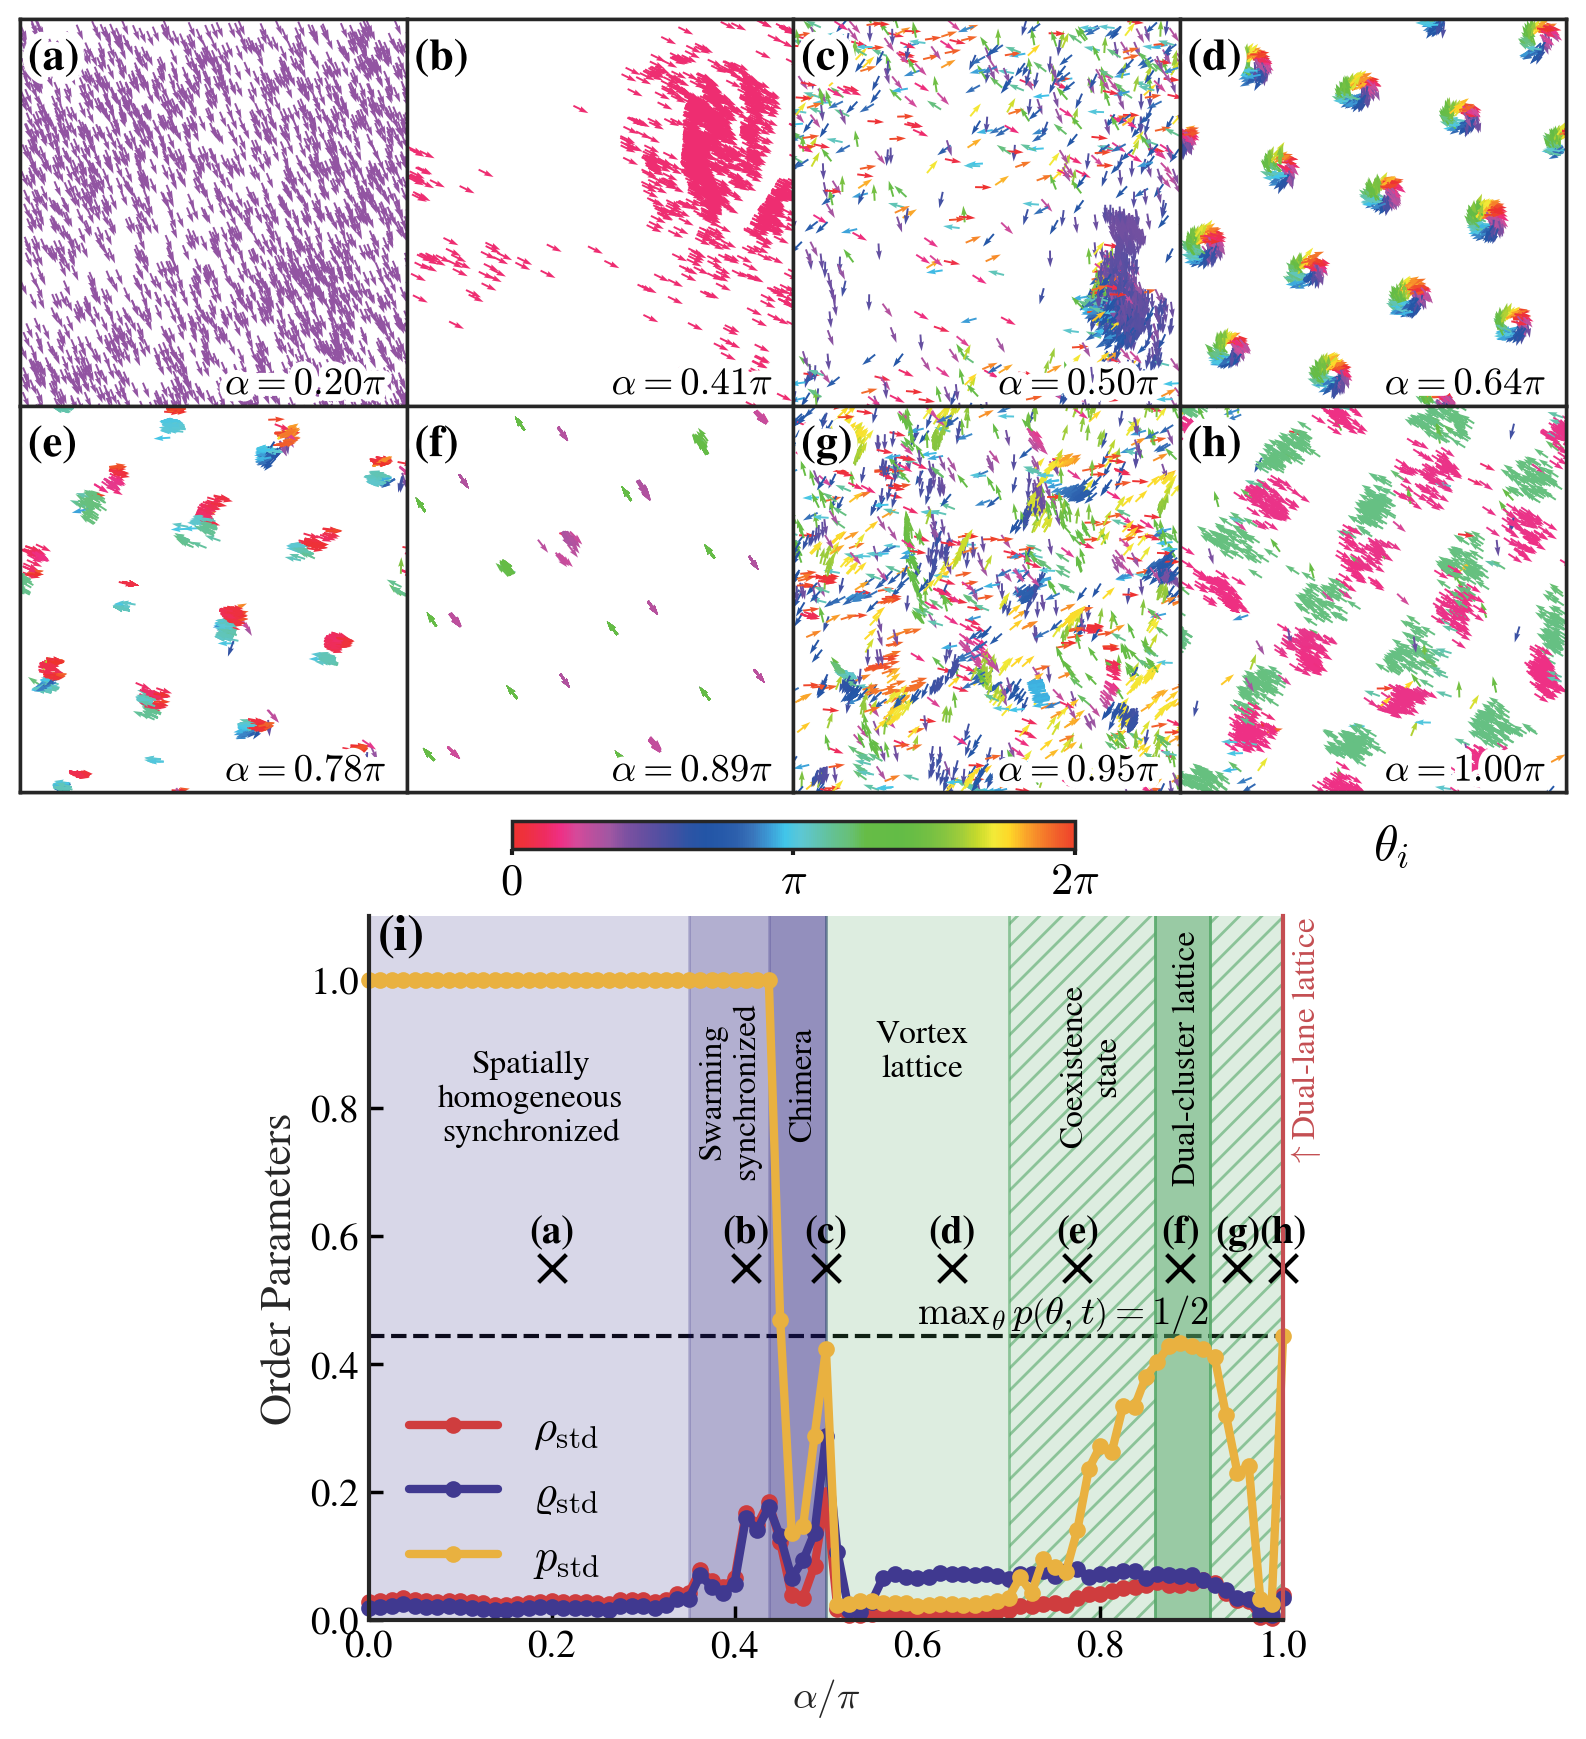

In [63]:
from matplotlib.patheffects import withStroke
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(16.4 / 2, 12))
# fig, axs = plt.subplots(1, 2, figsize=(16.4, 6), gridspec_kw={"width_ratios": [12, 7.37]})
gsTotal = gridspec.GridSpec(2, 1, height_ratios=[1, 0.5])
# gs1 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gsTotal[0])  # , width_ratios=[12, 7.37], wspace=0.1
ax1: plt.Axes = fig.add_subplot(gsTotal[0])
ax2: plt.Axes = fig.add_subplot(gsTotal[1])


selectedPhaseLags = np.array([0.2000, 0.4125, 0.5, 0.6375, 
                              0.775, 0.8875, 0.95, 1.0000]) * np.pi
totalRow, totalCol = 2, 4
for idx, phaseLag in enumerate(selectedPhaseLags):
    phaseShift = 3.5 if idx == 0 else 0
    sa = find_sa_by_phase_lag(sas, phaseLag)
    # plot_sub_snapshots(sa=sa, idx=idx, totalRow=2, totalCol=4, ax=ax1, phaseShift=phaseShift)
    
    row, col = totalRow - 1 - idx // totalCol, idx % totalCol
    subAx = ax1.inset_axes([1 / totalCol * col, 1 / totalRow * row, 1 / totalCol, 1 / totalRow])
    # sa.plot_spatial(ax=subAx)
    sub_plot_spatial_2D(sa=sa, ax=subAx, colorsBy="phase", index=-1)
    subAx.set_xticks([])
    subAx.set_yticks([])
    text1 = subAx.text(0.02 * sa.model.boundaryLength, 
                    0.87 * sa.model.boundaryLength,
                    f"({chr(97 + idx)})", fontsize=16, fontweight="bold")
    text2 = subAx.text(0.53 * sa.model.boundaryLength, 
                    0.03 * sa.model.boundaryLength,
                    rf"$\alpha={sa.model.phaseLagA0 / np.pi:.2f}\pi$", fontsize=14)
    for text in [text1, text2]:
        text.set_path_effects([withStroke(linewidth=5, foreground='white')])

    ax2.text(
        (phaseLag / np.pi), 0.59, 
        f"({chr(97 + idx)})", fontsize=14, fontweight="bold", ha="center"
    )
    ax2.scatter((phaseLag / np.pi), 0.55, 
                marker='x', s=100, color="black", clip_on=False)

norm = plt.Normalize(0, 2 * np.pi)
sm = ScalarMappable(cmap=hexCmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, orientation='horizontal', fraction=0.02, pad=0.02, ticks=[0, np.pi, 2*np.pi])
ax1.text(24.5, -1.2, r'$\theta_i$', fontsize=18)
cbar.ax.tick_params(length=2, direction="out", color="k", width=1.5)
cbar.ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=16)

ax1.set_xlim(0, 4 * sa.model.boundaryLength)
ax1.set_ylim(0, 2 * sa.model.boundaryLength)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect('equal')

lw = 3
ms = 5
ax2.plot(phaseLagsX, meanRhoStd, label=r"$\rho_{\mathrm{std}}$", color="#CF3D3E", marker='o', ms=ms, lw=lw, clip_on=False)
ax2.plot(phaseLagsX, meanVarrhoStd, label=r"$\varrho_{\mathrm{std}}$", color="#403990", marker='o', ms=ms, lw=lw, clip_on=False)
ax2.plot(phaseLagsX, meanPStd, label=r"$p_{\mathrm{std}}$", color="#E9B140", marker='o', ms=ms, lw=lw, clip_on=False)
rho0, varrho0, p0 = calc_uniform_solution(cellNumInLine=10, cellNumInPhase=10)
ax2.axhline(
    y=(0.5 - p0) / (1 - p0),
    color="black", linestyle="--", linewidth=1.5, alpha=1, zorder=-1,
)
ax2.text(0.6, (0.5 - p0) / (1 - p0) + 0.02, 
         r"$\max$$_{\theta}\,p\left( \theta ,t \right) =1/2$", fontsize=14)

ax2.tick_params(direction='in', length=5, labelsize=14)
ax2.set_ylabel(r"Order Parameters", fontsize=16)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color("C3")
ax2.spines['bottom'].set_linewidth(1.5)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['right'].set_linewidth(1.5)
ax2.set_xlabel(r"$\alpha / \pi$", fontsize=14)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.1)
ax2.legend(frameon=False, fontsize=16, loc="lower left")

ax2.fill_betweenx([0, 1.2], 0., 0.5, 
                  color="#403990", alpha=0.2, zorder=-1)
ax2.text(0.177, 0.75, "Spatially\nhomogeneous\nsynchronized", 
         fontsize=12, ha="center")
ax2.fill_betweenx([0, 1.2], 0.35, 0.5, 
                  color="#1B1373", alpha=0.2, zorder=-1)
ax2.text(0.395, 0.7, "Swarming\nsynchronized", fontsize=12, ha="center", rotation=90)
ax2.fill_betweenx([0, 1.2], 0.4375, 0.5, 
                  color="#1B1373", alpha=0.2, zorder=-1)
ax2.text(0.475, 0.76, "Chimera", fontsize=12, ha="center", rotation=90)
ax2.fill_betweenx([0, 1.2], 0.5, 0.86,
                  color="C2", alpha=0.2, zorder=-1)
ax2.text(0.605, 0.85, "Vortex\nlattice", 
         fontsize=12, ha="center")
ax2.fill_betweenx([0, 1.2], 0.7, 0.86,
                  facecolor="none", hatch="///",
                  edgecolor="C2", alpha=0.6, zorder=-1)
# Coexistence state
ax2.text(0.79, 0.75, "Coexistence\nstate", 
         fontsize=12, ha="center", rotation=90)
ax2.fill_betweenx([0, 1.2], 0.86, 0.92,
                  color="C2", alpha=0.6, zorder=-1)
ax2.fill_betweenx([0, 1.2], 0.92, 1,
                  color="C2", alpha=0.2, zorder=-1)
ax2.fill_betweenx([0, 1.2], 0.92, 1,
                  facecolor="none", hatch="///",
                  edgecolor="C2", alpha=0.6, zorder=-1)
ax2.text(0.895, 0.69, "Dual-cluster lattice", fontsize=12, ha="center", rotation=90)
ax2.text(1.025, 0.72, r"$\uparrow$Dual-lane lattice", 
         fontsize=12, ha="center", rotation=90, color="C3")
ax2.text(0.01, 1.05, "(i)", fontsize=18, fontweight="bold")
ax2.set_aspect(0.7)

plt.tight_layout(h_pad=0)
upShift = 0.015
rightShift = 0.02
pos = ax2.get_position()
ax2.set_position([pos.x0 + rightShift, pos.y0 + upShift, pos.width, pos.height])

plt.savefig("figs/snapshotsAndPhaseDiagram.pdf", bbox_inches="tight")